<h1 align="center">Workshop 2 -  Bonus</h1>
<h3 align="center">Universidad Nacional de Colombia - Deep learning - 2024-II</h3>
<h4 align="center">Andres Calle - Arley Reina - Manuela Granda</h4>



## Bonus:
Pick and use a Yolo dataset from the Internet re run the code and show the results
and draw your own conclusion

## Objective:
The objective in this notebook is explore a train with kaggle dataset and create inference over video to test performace and model metrics.

## Datasets:
[Car Object Detection](https://www.kaggle.com/datasets/sshikamaru/car-object-detection) : Dataset with laveled cars over way with boundigbox. The data contains 1001 images to train and 175 files to test.

[car_videos](https://www.kaggle.com/datasets/amogh0810/car-videos) Data from kaggle user of video cars

[car_video test yolov](https://www.kaggle.com/datasets/arley6mith/car-video-test-yolov) Custom video from youtube edited from autors of this notebook to test model with real data.


## Credits:


This notebook was copied frmr kaggl euse 

[Arwa Abou-Attia](https://www.kaggle.com/arwaabouattia)

Here we take preprocessing data, train model, and EDA, the idea is change some params of train model and test over videos.

In [2]:
!pip install ultralytics -q

In [3]:
# !pip install -U ipywidgets -q

In [4]:
# Importing the required libraries

import os  # For interacting with the operating system (e.g., file paths)
import pandas as pd  # For loading and manipulating CSV data (bounding boxes and image info)
import numpy as np  # For numerical operations and array handling
import random
import cv2  # For image processing and manipulation (OpenCV library)
import matplotlib.pyplot as plt  # For visualizing data and images (plots)
import seaborn as sns  # For advanced data visualization (especially histograms and distributions)
from glob import glob  # For finding all image files in a directory (using wildcard patterns)
from sklearn.model_selection import train_test_split  # For splitting the dataset into training and testing sets
from PIL import Image
from ultralytics import YOLO


import warnings
warnings.filterwarnings("ignore", "use_inf_as_na option is deprecated")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 2- Exploratory Data Analysis (EDA)

In [5]:
# Create necessary directories
!mkdir -p "/kaggle/working/data"
!mkdir -p "/kaggle/working/data/images"
!mkdir -p "/kaggle/working/data/images/train"
!mkdir -p "/kaggle/working/data/images/val"
!mkdir -p "/kaggle/working/data/labels"
!mkdir -p "/kaggle/working/data/labels/train"
!mkdir -p "/kaggle/working/data/labels/val"

root_dir = "/kaggle/working/data"
labels_dir = "/kaggle/working/data/labels"
images_dir = "/kaggle/working/data/images"

In [6]:
# Define paths
train_data = "/kaggle/input/car-object-detection/data/training_images"
csv_data = "/kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv"
test_data = "/kaggle/input/car-object-detection/data/testing_images"

In [7]:
# Loading the CSV data
df = pd.read_csv(csv_data)

# Display the first few rows of the dataframe to understand its structure
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


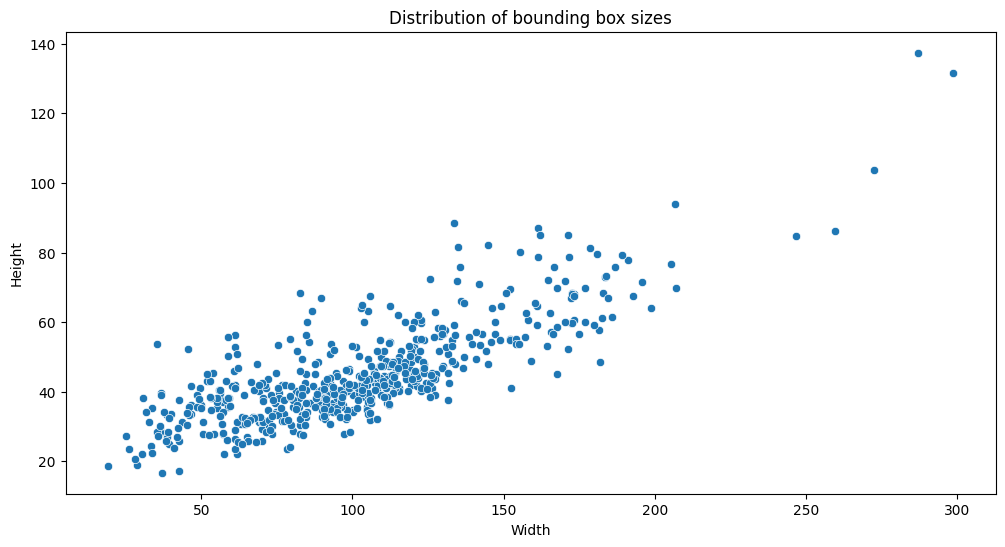

In [8]:
# Distribution of bounding box sizes
plt.figure(figsize=(12, 6))
df['width'] = df['xmax'] - df['xmin']
df['height'] = df['ymax'] - df['ymin']
sns.scatterplot(x='width', y='height', data=df)
plt.title('Distribution of bounding box sizes')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

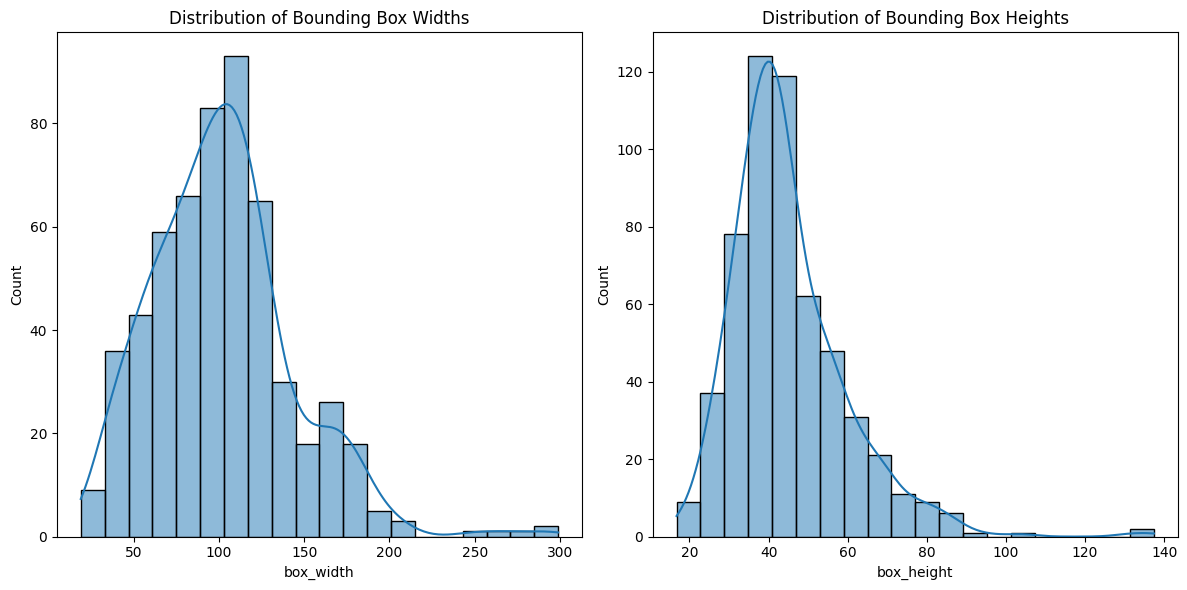

In [9]:
# Visualizing the distribution of bounding box widths and heights
df['box_width'] = df['xmax'] - df['xmin']
df['box_height'] = df['ymax'] - df['ymin']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['box_width'], bins=20, kde=True)
plt.title('Distribution of Bounding Box Widths')

plt.subplot(1, 2, 2)
sns.histplot(df['box_height'], bins=20, kde=True)
plt.title('Distribution of Bounding Box Heights')

plt.tight_layout();
plt.show();

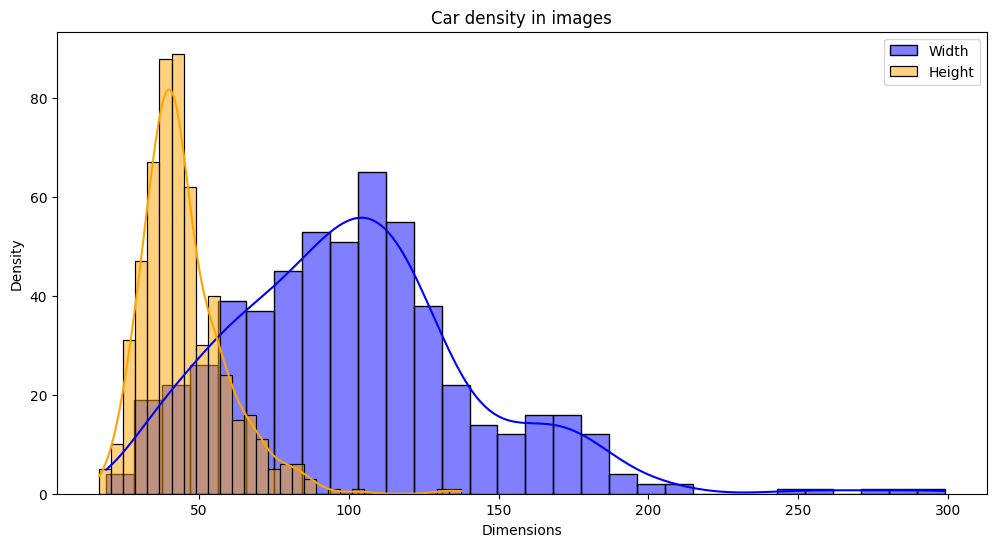

In [10]:
# Car density analysis in images
plt.figure(figsize=(12, 6))
sns.histplot(df['width'], bins=30, kde=True, color='blue', label='Width')
sns.histplot(df['height'], bins=30, kde=True, color='orange', label='Height')
plt.title('Car density in images')
plt.xlabel('Dimensions')
plt.ylabel('Density')
plt.legend()
plt.show()

In [13]:
# Visualizing sample images with bounding boxes
def plot_images_with_boxes(image_path, df, n=3):
    images = glob(f'{image_path}/*.jpg')#[:n]
    random_select = random.sample(images,n)
    for img_path in random_select:
        img = cv2.imread(img_path)
        img_name = os.path.basename(img_path)
        boxes = df[df['image'] == img_name]  # تغيير 'filename' إلى 'image'
        
        for _, box in boxes.iterrows():
            cv2.rectangle(img, 
                          (int(box['xmin']), int(box['ymin'])), 
                          (int(box['xmax']), int(box['ymax'])), 
                          (0, 255, 0), 2)
        
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(img_name)
        plt.axis('off')
        plt.show()

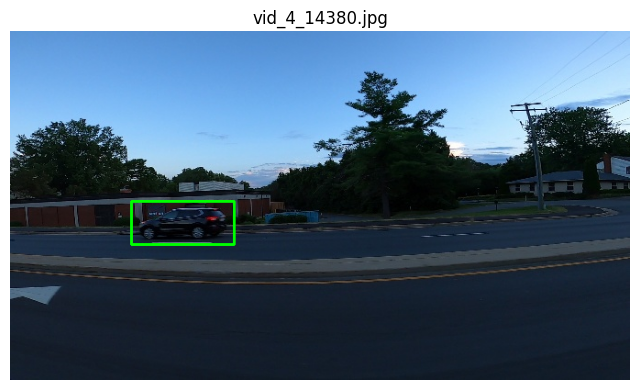

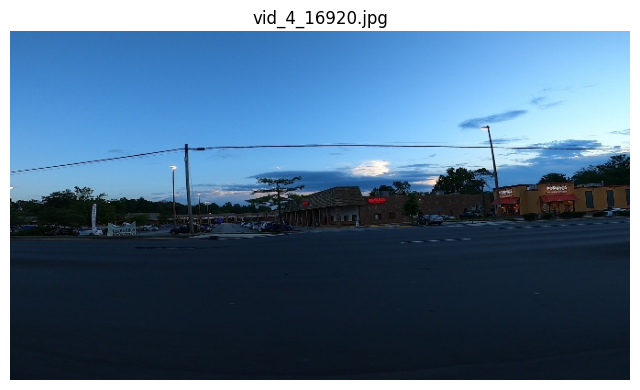

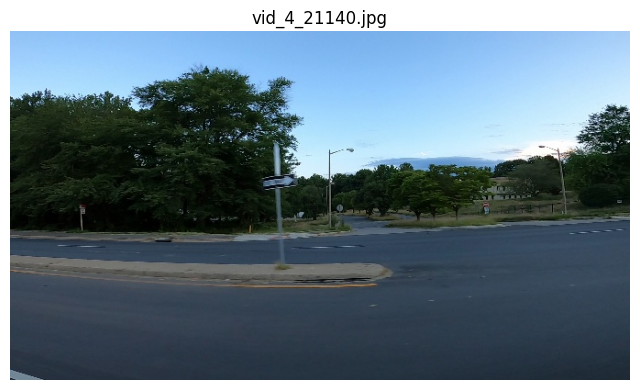

In [14]:
# Plotting sample images with bounding boxes
plot_images_with_boxes(train_data, df)

# 3- Preparing the Dataset for `YOLO`

In [15]:
# Prepare YOLO format annotations
def create_yolo_annotation(row, img_width, img_height):
    x_center = ((row['xmin'] + row['xmax']) / 2) / img_width
    y_center = ((row['ymin'] + row['ymax']) / 2) / img_height
    width = (row['xmax'] - row['xmin']) / img_width
    height = (row['ymax'] - row['ymin']) / img_height
    return f"0 {x_center} {y_center} {width} {height}"

In [16]:
# Create YOLO annotations and copy images
for img_name in df['image'].unique():
    img_df = df[df['image'] == img_name]
    img_path = os.path.join(train_data, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img_height, img_width = img.shape[:2]
        
        # Decide whether to put in train or val folder
        if np.random.rand() < 0.8:  # 80% train, 20% val
            subset = "train"
        else:
            subset = "val"
        
        # Copy image
        dst_img_path = os.path.join(images_dir, subset, img_name)
        cv2.imwrite(dst_img_path, img)
        
        # Create annotation file
        annotation_path = os.path.join(labels_dir, subset, f"{img_name.split('.')[0]}.txt")
        with open(annotation_path, 'w') as f:
            for _, row in img_df.iterrows():
                yolo_annotation = create_yolo_annotation(row, img_width, img_height)
                f.write(yolo_annotation + '\n')

In [17]:
# Create YAML configuration file
yaml_content = f"""
path: {root_dir}
train: images/train
val: images/val

nc: 1
names: ['car']
"""

with open('car_detection.yaml', 'w') as f:
    f.write(yaml_content)

print("YAML configuration file created.")

YAML configuration file created.


# 4- Training the YOLO Model

In [18]:
model = YOLO('yolov8n.pt')

100%|██████████| 6.25M/6.25M [00:00<00:00, 116MB/s]


In [19]:
results = model.train(
    data='car_detection.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    name='car_detection_model_test'
)

Ultralytics 8.3.35 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=car_detection.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=car_detection_model_test, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf

100%|██████████| 755k/755k [00:00<00:00, 21.4MB/s]
2024-11-21 14:32:39,350	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-11-21 14:32:39,833	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 89.8MB/s]


AMP: checks passed ✅


...

      30/30      2.33G      1.011     0.5679     0.9955         15        640: 100%|██████████| 18/18 [00:03<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  8.95it/s]

                   all         73        109      0.981      0.991      0.994      0.696



30 epochs completed in 0.036 hours.
Optimizer stripped from runs/detect/car_detection_model_test/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/car_detection_model_test/weights/best.pt, 6.2MB

Validating runs/detect/car_detection_model_test/weights/best.pt...
Ultralytics 8.3.35 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  5.23it/s]


                   all         73        109      0.981      0.991      0.994      0.696
Speed: 0.1ms preprocess, 2.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/car_detection_model_test


# 5 Model Evaluation

[Object Detection Metrics](https://docs.ultralytics.com/es/guides/yolo-performance-metrics/#introduction)

Intersection over Union (I oU): IoU is a measure that quantifies the overlap between a predicted bounding box and an actual bounding box. It plays a critical role in evaluating the accuracy of object localizatio_.

Average Precisio_ (PA): PA calculates the area under the precision-recall curve, providing a single value that encapsulates the precision and recall performance of the mo_el.

Mean Average Precisi_n (mAP): mAP extends the concept of AP by calculating the mean AP values ​​across multiple object classes. This is useful in multi-class object detection scenarios to provide a comprehensive evaluation of the model perfor_ance.

Precision _nd Recall: Precision quantifies the proportion of true positives among all positive predictions, evaluating the model's ability to avoid false positives. On the other hand, Recall calculates the proportion of true positives among all actual positives, measuring the model's ability to detect all cases of _ class._

F1 Score: The F1 score is the harmonic mean of precision and recall, and provides a balanced assessment of a model's performance taking into account both false positives and false negatives.

In [21]:
# Model Evaluation
results = model.val(data='car_detection.yaml',imgsz=608, conf=0.1, iou=0.3)
print(results.box.map)
#print(results)

Ultralytics 8.3.35 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)


val: Scanning /kaggle/working/data/labels/val.cache... 73 images, 0 backgrounds, 0 corrupt: 100%|██████████| 73/73 [00:00<?, ?it/s]
/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  4.82it/s]


                   all         73        109      0.982      0.987      0.993      0.733
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/car_detection_model_test3
0.7325198990556816


In [47]:
print(f'P (Precisión) proportion of true positives among all positive predictions :  {results.box.p[0]}')
print(f'R (Recall) calculates the proportion of true positives among all actual positives:  {results.box.r[0]}')
print(f'F1-Score :  {results.box.f1[0]}')

P (Precisión) proportion of true positives among all positive predictions :  0.9817531141723943
R (Recall) calculates the proportion of true positives among all actual positives:  0.9872469675550833
F1-Score :  0.9844923764595394



image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_28520.jpg: 384x640 1 car, 6.8ms
Speed: 1.8ms preprocess, 6.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


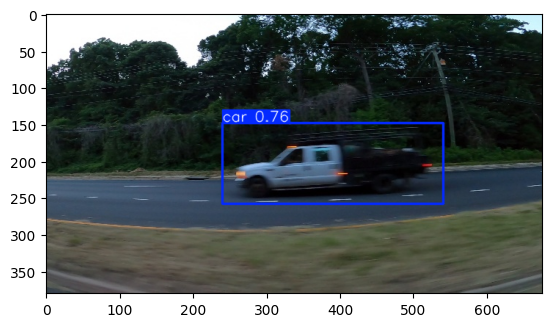

In [49]:
# Test on a sample image from the test set
sample_test_image = os.path.join(test_data, os.listdir(test_data)[100]) #100 works

# Perform inference on the sample image
test_results = model(sample_test_image)

# Display the first result using 'plot' or similar method
annotatedImage = test_results[0].plot()  # This should display the image with predictions
annotatedImageRGB = cv2.cvtColor(annotatedImage, cv2.COLOR_BGR2RGB)
plt.imshow(annotatedImageRGB)


image 1/1 //kaggle/input/car-object-detection/data/testing_images/vid_5_26800.jpg: 352x608 3 cars, 37.0ms
Speed: 2.0ms preprocess, 37.0ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 608)


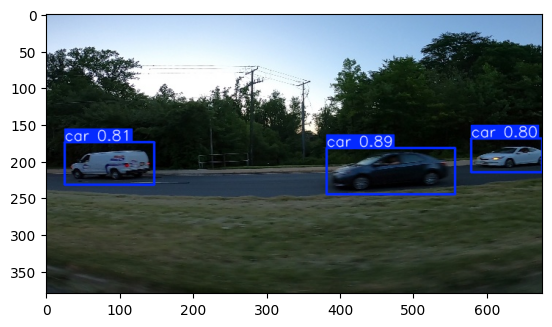

In [50]:
# Test on a sample image from the test set
sample_test_image = '//kaggle/input/car-object-detection/data/testing_images/vid_5_26800.jpg'

# Perform inference on the sample image
test_results = model(sample_test_image, imgsz=608, conf=0.1, iou=0.3,)

# Display the first result using 'plot' or similar method
annotatedImage = test_results[0].plot()  # This should display the image with predictions
annotatedImageRGB = cv2.cvtColor(annotatedImage, cv2.COLOR_BGR2RGB)
plt.imshow(annotatedImageRGB)

## Test model with video

In [52]:
videoPath = '/kaggle/input/car-video-test-yolov/test_cars_video.mp4'

model.predict(source=videoPath, save=True)



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2614) /kaggle/input/car-video-test-yolov/test_cars_video.mp4: 384x640 (no detections), 7.5ms
video 1/1 (frame 2/2614) /kaggle/input/car-video-test-yolov/test_cars_video.mp4: 384x640 (no detections), 7.1ms
video 1/1 (frame 3/2614) /kaggle/input/car-video-test-yolov/test_cars_video.mp4: 384x640 (no detections), 7.7ms
video 1/1 (frame 4/2614) /kaggle/input/car-video-test-yolov/test_cars_video.mp4: 384x640 (no detections), 6.4ms
video 1/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car'}
 obb: None
 orig_img: array([[[248, 253, 230],
         [248, 253, 230],
         [248, 253, 230],
         ...,
         [ 38,  46,  43],
         [ 44,  47,  45],
         [ 44,  47,  45]],
 
        [[248, 253, 230],
         [248, 253, 230],
         [248, 253, 230],
         ...,
         [ 38,  46,  43],
         [ 44,  47,  45],
         [ 44,  47,  45]],
 
        [[248, 253, 230],
         [248, 253, 230],
         [248, 253, 230],
         ...,
         [ 40,  45,  43],
         [ 44,  47,  45],
         [ 44,  47,  45]],
 
        ...,
 
        [[ 74,  61,  52],
         [ 74,  61,  52],
         [ 74,  61,  52],
         ...,
         [ 13,  49,  44],
         [ 14,  50,  45],
         [ 15,  51,  46]],
 
        [[ 74,  61,  52],
         [ 74,  61,  52],
         [ 74,  61,  52],
         ...,
         [ 12,  48,  

# 5- Save The Model 

In [53]:
model.save('car_detection_model_v2.pt')
print("Model saved successfully.")

Model saved successfully.


___